# Antibiotic heteroresistance generated by plasmid copy-number variability
## Supplementary figure 2

### Fluorescense Distributions - Coefficient of Variation


## System preparation


In [1]:
import pandas as pd
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
from scipy.stats import gaussian_kde
import scipy.stats as stats
import random


### Mounting Gdrive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### File paths

In [3]:
rootDir="/content/drive/MyDrive/SYNC_Projects/"

rootDir=rootDir+"pBGT/ms/"

workingDir=rootDir+"code/Supplementary/"
data_path=rootDir+"data/LB-AMP-LB/"
sfig_path=rootDir+"figures/SuppFigures/"


# pBGT

## Loading data

In [4]:
pBGT_file=data_path+"pBGT_LB-AMP-LB_AMNIS.csv"
pBGT_df=pd.read_csv(pBGT_file,sep="\t")
pBGT_df.head()
pBGT_dfbk=pBGT_df.copy()

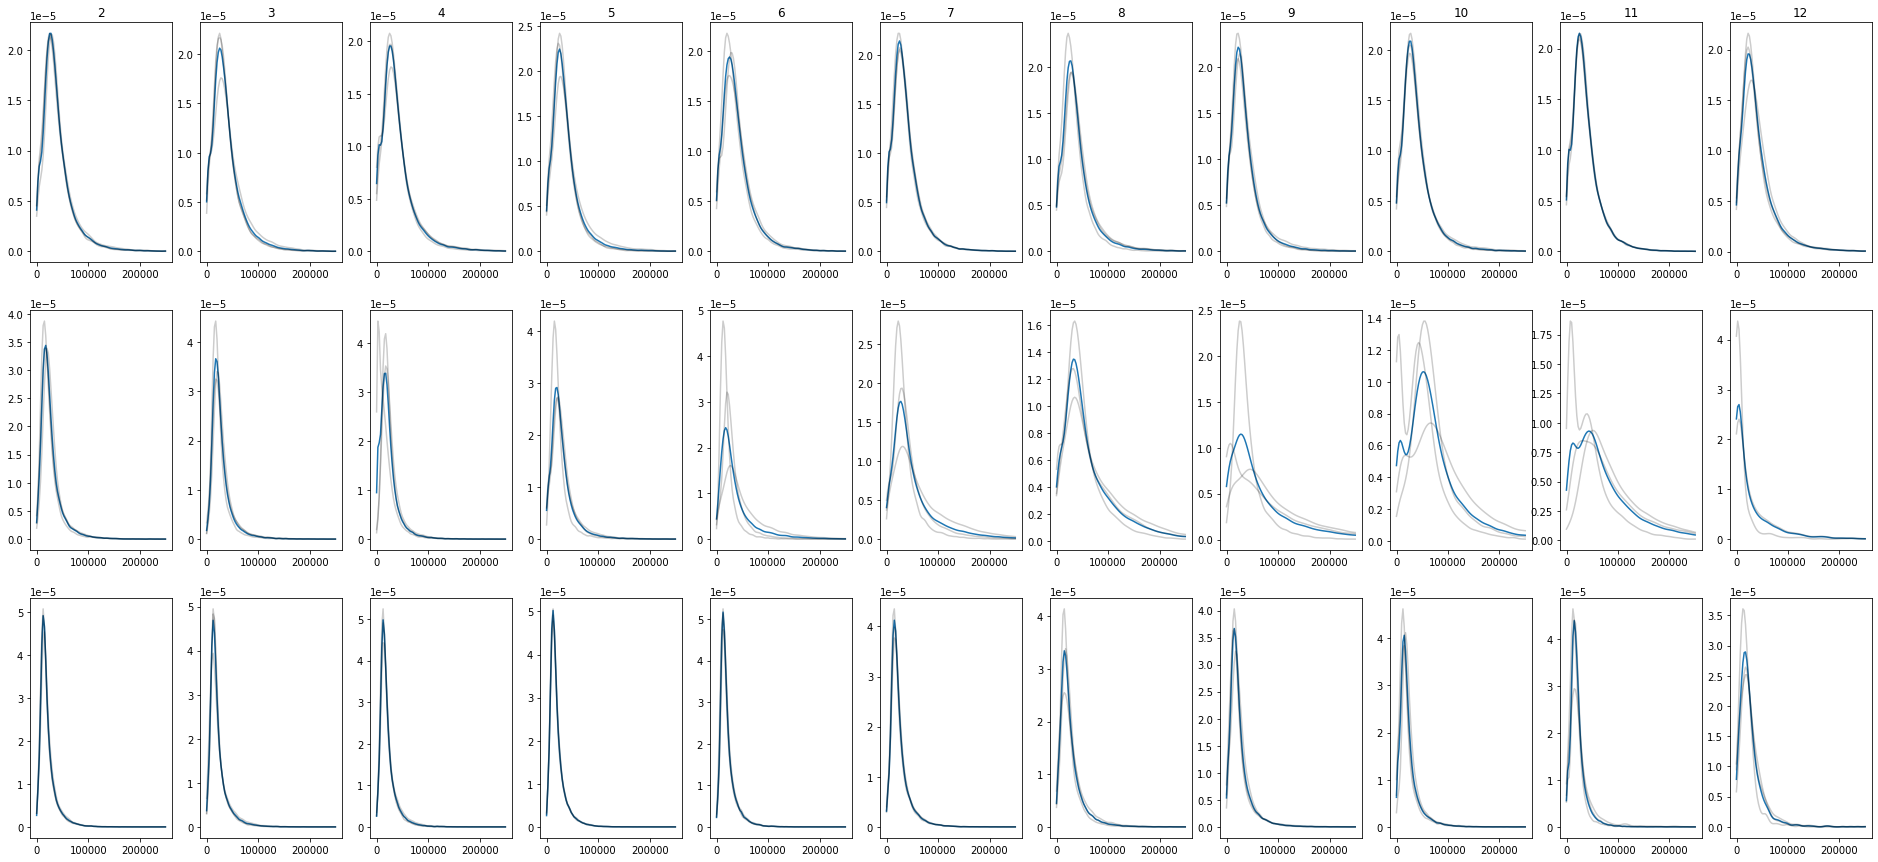

In [5]:
cols=pBGT_df["dose number"].unique()
rows=pBGT_df["season"].unique()
cols.sort()
ncols=len(cols)
nrows=len(rows)

this_g=pBGT_df["Intensity_MC_Ch02"]
maxg=this_g.max()
ming=this_g.min()
maxg=250000


xs=np.linspace(ming,maxg,100)

fig,ax=plt.subplots(nrows,ncols,figsize=(ncols*3,nrows*5)) 
for ic,col in enumerate(cols):
    col_df=pBGT_df[pBGT_df["dose number"]==col]
    ax[0,ic].set_title(col)
    for ir,row in enumerate(rows):
        row_df=col_df[col_df["season"]==row]
        this_gs=row_df["Intensity_MC_Ch02"]
        den=gaussian_kde(this_gs)
        ys=den(xs)
        ax[ir,ic].plot(xs,ys)
        reps=row_df["replicate"].unique()
        for rep in reps:
            t_df=row_df[row_df["replicate"]==rep]
            this_gs=t_df["Intensity_MC_Ch02"]
            den=gaussian_kde(this_gs)
            ys=den(xs)
            ax[ir,ic].plot(xs,ys,c='k',alpha=.2)
plt.show()

### Estimating CV for LB+AMP season pBGT

[ 2  3  4  5  6  7  8  9 10 11 12]
Rows: [2]
1000 300000.0
4358 41481.75350457571 23508.452993980645 0.5667179183104568
	 1484 47291.636672892935 24145.14714831226 0.5105585013967596
	 1402 43021.44361896541 22949.51583223787 0.5334436481373882
	 1472 34158.036003110275 21374.443187946777 0.6257515269906185
0.5565845588415889 

7123 42218.13386328248 22437.644193293683 0.5314693507286432
	 2250 45977.97575924367 24756.407877160767 0.5384405787413031
	 2740 43714.10145959167 22195.39316951699 0.5077398923556489
	 2133 36330.37226937726 18693.593497339796 0.5145445072440549
0.5202416594470023 

5730 40573.54103237121 23862.782496476084 0.5881365512918232
	 1163 45051.64754102254 28468.962332371913 0.631918340088429
	 2386 40548.61707578114 23519.136876824323 0.5800231567175154
	 2181 38212.89485670061 21034.28601366512 0.5504499487030298
0.5874638151696581 

4743 52249.36448111303 31006.509642452933 0.5934332398178946
	 1716 54568.90709063558 25936.970144270967 0.4753067548373521
	 1651 

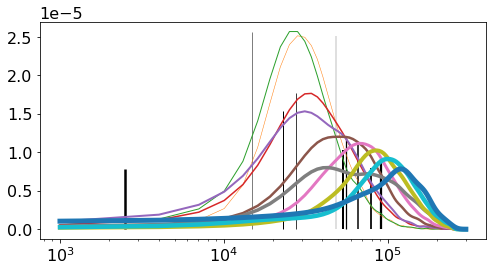

In [60]:

pBGT_df=pBGT_dfbk.copy()


lim_aspect=[.2, 1];
lim_area=[25, 35];



pBGT_df=pBGT_df[(pBGT_df["Area_M02"]>lim_area[0])&(pBGT_df["Area_M02"]<lim_area[1])
                &(pBGT_df["Aspect Ratio_M02"]>lim_aspect[0])&(pBGT_df["Aspect Ratio_M02"]<lim_aspect[1])
                &(pBGT_df["Intensity_MC_Ch02"]<2.5e5)
                #&(pBGT_df["Gradient RMS_M02_Ch02"]>40)
                #&(pBGT_df["Gradient RMS_M04_Ch04"]>0)
               ]


cols=pBGT_df["dose number"].unique()
cols.sort()
print(cols)

rows=pBGT_df["season"].unique()
rows=[2]
print("Rows:",rows)

ncols=len(cols)
nrows=len(rows)



this_g=pBGT_df["Intensity_MC_Ch02"]
maxg=this_g.max()
ming=this_g.min()
ming=1000
maxg=3e5

print(ming,maxg)
xs=np.linspace(ming,maxg,100)

pBGT_cvs=[]
pBGT_cvsx=[]
pBGT_cvsm=[]
pBGT_cvsxm=[]
pBGT_cvsm2=[]
pBGT_cvsxm2=[]


fig,ax=plt.subplots(figsize=(8,4)) 
for ic,col in enumerate(cols):
    col_df=pBGT_df[pBGT_df["dose number"]==col]
    #ax.set_title(col)
    for ir,row in enumerate(rows):
        row_df=col_df[col_df["season"]==row]
        
        this_gs=row_df["Intensity_MC_Ch02"]
        this_mean=np.mean(this_gs)
        this_sd=np.std(this_gs)
        this_cv=this_sd/this_mean
        pBGT_cvsm.append(this_cv)
        pBGT_cvsxm.append(ic)
        print(this_gs.size,this_mean,this_sd,this_cv)
        this_gs2=[int(x) for x in this_gs]
        den=gaussian_kde(this_gs)
        ys=den(xs)
        yma=max(ys)
        ax.plot(xs,ys,lw=ic*.5)
        xmode=stats.mode(this_gs2).mode
        ax.vlines(x=xmode,ymin=0,ymax=yma,lw=ic*.25)
        reps=row_df["replicate"].unique()
        mcv=[]
        
        for rep in reps:
            t_df=row_df[row_df["replicate"]==rep]
            this_gs=t_df["Intensity_MC_Ch02"]
            this_mean=np.mean(this_gs)
            this_sd=np.std(this_gs)
            this_cv=this_sd/this_mean
            pBGT_cvs.append(this_cv)
            pBGT_cvsx.append(ic)
            mcv.append(this_cv)
            print("\t",this_gs.size,this_mean,this_sd,this_cv)
            #ax.plot(xs,ys,c='k',alpha=.2)
        this_cv=np.mean(mcv)
        pBGT_cvsm2.append(this_cv)
        pBGT_cvsxm2.append(ic)
        print(this_cv,"\n")
#plt.yscale("log")
plt.xscale("log")
plt.show()




### Plotting CV vs Dose pBGT

lr0 LinregressResult(slope=-0.022211239510932786, intercept=0.5877680101939987, rvalue=-0.7709448585560909, pvalue=6.195649848711278e-07, stderr=0.003467711868411505, intercept_stderr=0.018512515487263674)
lrm LinregressResult(slope=-0.017435174545927447, intercept=0.6060480713197746, rvalue=-0.7132688370558682, pvalue=0.020562631986708133, stderr=0.0060572885403534, intercept_stderr=0.03233707187024289)
lrm2 LinregressResult(slope=-0.02221123951093279, intercept=0.5877680101939987, rvalue=-0.8840220358956398, pvalue=0.000686625067463117, stderr=0.0041523642229571835, intercept_stderr=0.02216755886972452)


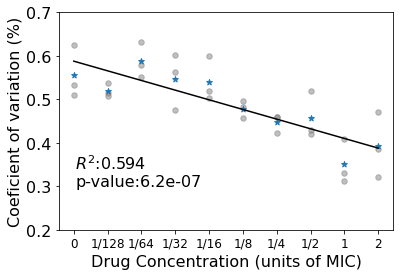

In [67]:
Doses=['0', '1/128', '1/64', '1/32', '1/16','1/8','1/4','1/2','1','2'];


fig=plt.figure(figsize=(6,4))
fig.set_facecolor('white')
plt.rcParams.update({'font.size': 16})

pBGT_tcvsx=pBGT_cvsx[0:-2]
pBGT_tcvs=pBGT_cvs[0:-2]

pBGT_tcvsxm=pBGT_cvsxm[0:-1]
pBGT_tcvsm=pBGT_cvsm[0:-1]
pBGT_tcvsxm2=pBGT_cvsxm2[0:-1]
pBGT_tcvsm2=pBGT_cvsm2[0:-1]

tcvsx_ticks=list(set(pBGT_tcvsx))

pBGT_lr0=linregress(pBGT_tcvsx,pBGT_tcvs)

print("lr0",pBGT_lr0)
pBGT_lrm=linregress(pBGT_tcvsxm,pBGT_tcvsm)

print("lrm",pBGT_lrm)
pBGT_lrm2=linregress(pBGT_tcvsxm2,pBGT_tcvsm2)

print("lrm2",pBGT_lrm2)

lr_plot=pBGT_lr0 #<-------------------------- choose one for this
lry_plot=[x*lr_plot.slope+lr_plot.intercept for x in tcvsx_ticks]
plt.scatter(pBGT_tcvsx,pBGT_tcvs,s=30,c='gray',alpha=.5)
plt.scatter(pBGT_tcvsxm2,pBGT_tcvsm2,marker='*')
plt.plot(tcvsx_ticks,lry_plot,'k',label="regression")

plt.annotate(r"$R^2$:""%s\np-value:%s"%(round(lr_plot.rvalue**2,3),"{:.1e}".format(lr_plot.pvalue)), xy=(0.05, 0.2), xycoords='axes fraction')

plt.ylim([.2,.7])

plt.xticks(tcvsx_ticks,labels=Doses,fontsize=12)

plt.ylabel("Coeficient of variation (%)")
plt.xlabel("Drug Concentration (units of MIC)")


plt.show()

# MGGT

# Loading MGGT data

In [68]:
MGGT_file=data_path+"MGGT_LB-AMP-LB_AMNIS.csv"
MGGT_df=pd.read_csv(MGGT_file,sep="\t")
MGGT_dfbk=MGGT_df.copy()

MGGT_df.head()

,Object Number,Area_M01,Area_M02,Area_M04,Aspect Ratio_M01,Aspect Ratio_M02,Aspect Ratio_M04,Gradient RMS_M01_Ch01,Gradient RMS_M02_Ch02,Gradient RMS_M04_Ch04,Intensity_MC_Ch02,strain,season,treatment,replicate,dose number
0,0,0.0,55.222222,0.0,0.0,0.502838,0.0,0.0,20.293874,0.0,3574.465116,MGGT,1,LB,rep-1,2
1,1,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,43.690217,MGGT,1,LB,rep-1,2
2,2,0.0,16.888889,0.0,0.0,0.698250,0.0,0.0,19.941072,0.0,1112.717391,MGGT,1,LB,rep-1,2
3,3,0.0,5.444444,0.0,0.0,0.664979,0.0,0.0,37.844659,0.0,569.486111,MGGT,1,LB,rep-1,2
4,4,0.0,14.666667,0.0,0.0,0.677321,0.0,0.0,28.464187,0.0,1919.706897,MGGT,1,LB,rep-1,2


[ 2  3  4  5  6  7  8  9 10 11 12]
9 1 521
9 1 3209
9 1 1442


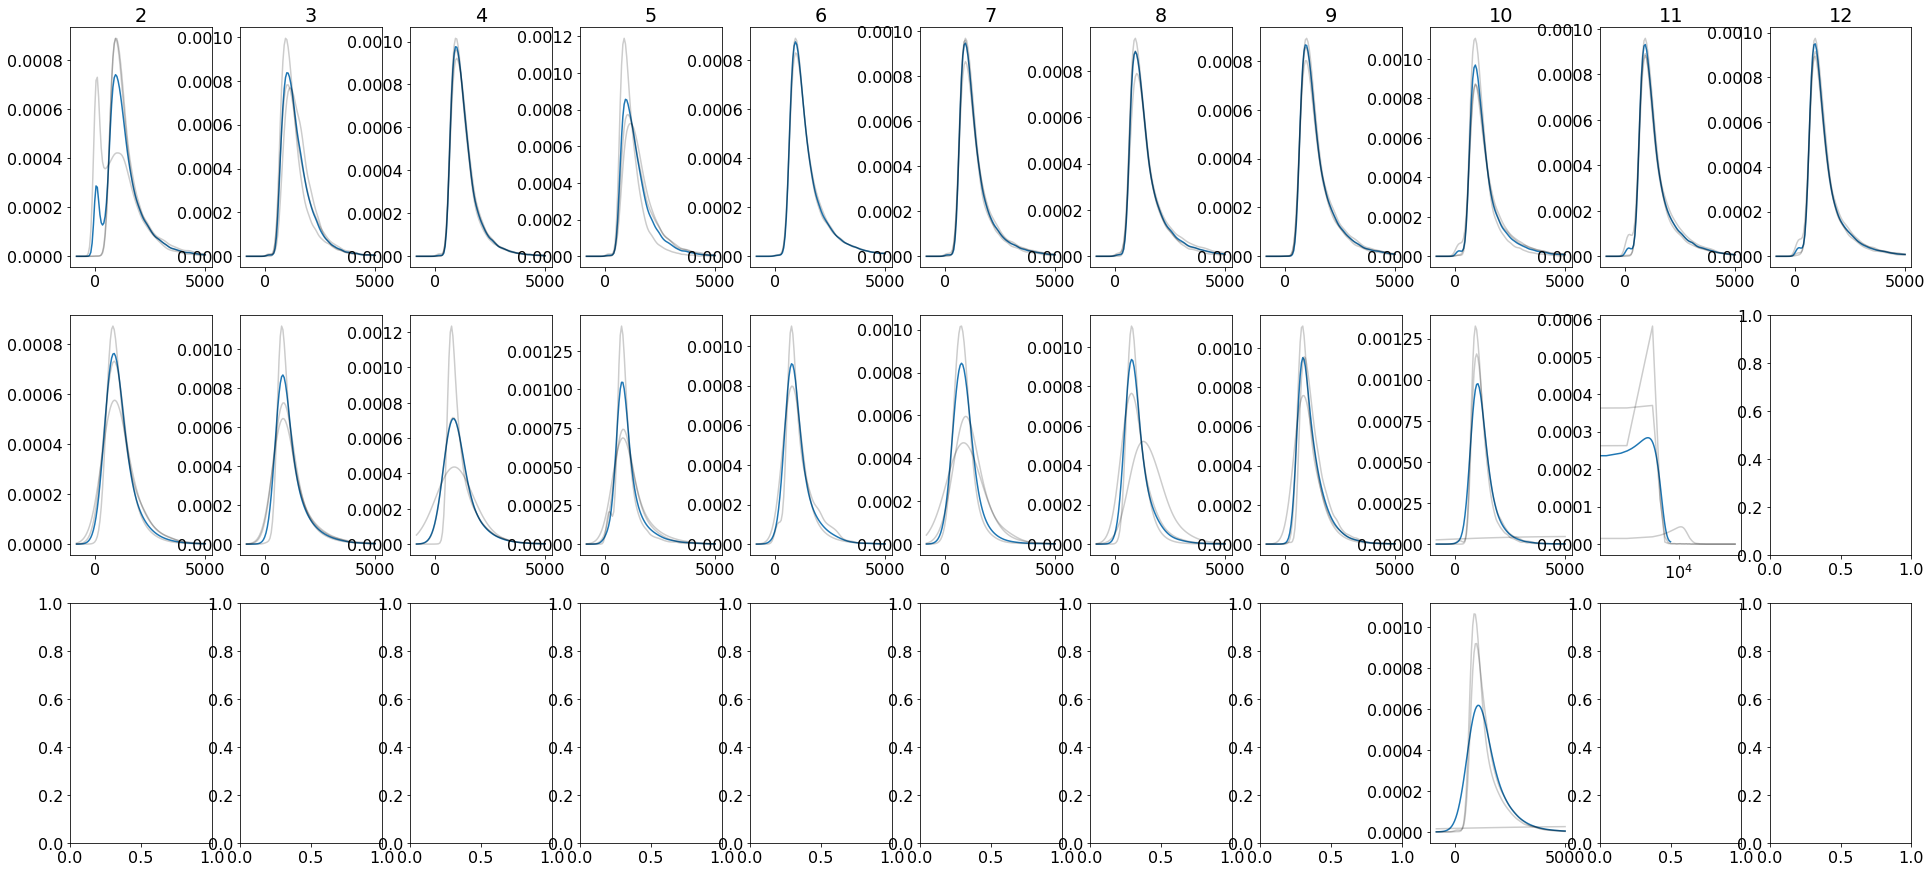

In [17]:
MGGT_df=MGGT_dfbk.copy()

cols=MGGT_df["dose number"].unique()
cols.sort()
print(cols)
rows=MGGT_df["season"].unique()
ncols=len(cols)
nrows=len(rows)

this_g=MGGT_df["Intensity_MC_Ch02"]
maxg=this_g.max()
ming=this_g.min()

maxg0=5e3

xs=np.linspace(ming,maxg0,100)

fig,ax=plt.subplots(nrows,ncols,figsize=(ncols*3,nrows*5)) 
for ic,col in enumerate(cols):
    col_df=MGGT_df[MGGT_df["dose number"]==col]
    ax[0,ic].set_title(col)
    for ir,row in enumerate(rows):
        row_df=col_df[col_df["season"]==row]
        this_gs=row_df["Intensity_MC_Ch02"]
        
        if(len(this_gs)==0):
            continue
        den=gaussian_kde(this_gs)
        ys=den(xs)
        ax[ir,ic].plot(xs,ys)
        reps=row_df["replicate"].unique()
        for rep in reps:
            t_df=row_df[row_df["replicate"]==rep]
            this_gs=t_df["Intensity_MC_Ch02"]
            if((ir==1)&(ic==9)):
                print(ic,ir,len(this_gs))
                ax[ir,ic].set_xscale("log")
                maxg=this_g.max()
                maxg=1e6
                xs=np.linspace(ming,maxg,1000)
            den=gaussian_kde(this_gs)
            ys=den(xs)
            ax[ir,ic].plot(xs,ys,c='k',alpha=.2)
            maxg=maxg0
            xs=np.linspace(ming,maxg,100)

        
plt.show()




[ 2  3  4  5  6  7  8  9 10 11 12]


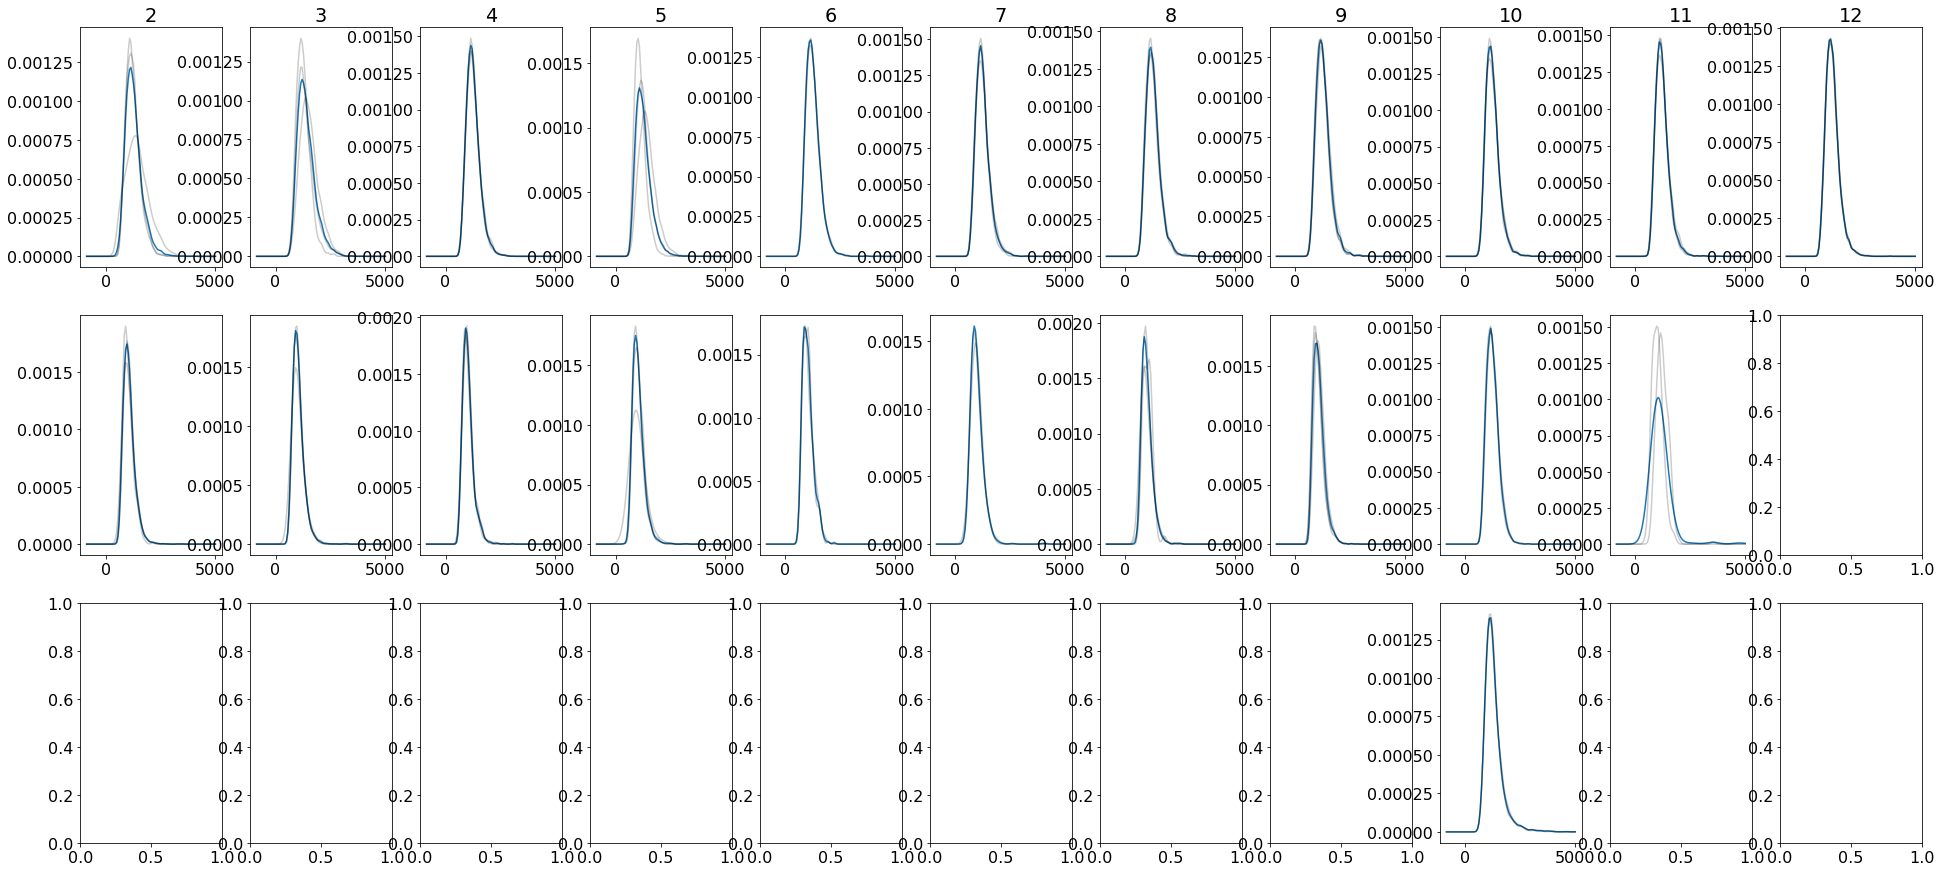

In [95]:


MGGT_df=MGGT_dfbk.copy()
cols=MGGT_df["dose number"].unique()
cols.sort()
print(cols)
rows=MGGT_df["season"].unique()
ncols=len(cols)
nrows=len(rows)

this_g=MGGT_df["Intensity_MC_Ch02"]
maxg=this_g.max()
ming=this_g.min()

maxg0=5e3


lim_aspect=[.4, .6];
lim_area=[5, 15];

MGGT_df=MGGT_df[(MGGT_df["Area_M02"]>lim_area[0])&(MGGT_df["Area_M02"]<lim_area[1])&
                (MGGT_df["Aspect Ratio_M02"]>lim_aspect[0])&(MGGT_df["Aspect Ratio_M02"]<lim_aspect[1])
                &(MGGT_df["Intensity_MC_Ch02"]<10000)
                #&(MGGT_df["Gradient RMS_M04_Ch04"]<1)
                &(MGGT_df["Gradient RMS_M02_Ch02"]>39)
                ]

xs=np.linspace(ming,maxg0,100)
fig,ax=plt.subplots(nrows,ncols,figsize=(ncols*3,nrows*5)) 
for ic,col in enumerate(cols):
    col_df=MGGT_df[MGGT_df["dose number"]==col]
    ax[0,ic].set_title(col)
    for ir,row in enumerate(rows):
        row_df=col_df[col_df["season"]==row]
        this_gs=row_df["Intensity_MC_Ch02"]
        
        if(len(this_gs)==0):
            continue
        den=gaussian_kde(this_gs)
        ys=den(xs)
        ax[ir,ic].plot(xs,ys)
        reps=row_df["replicate"].unique()
        for rep in reps:
            t_df=row_df[row_df["replicate"]==rep]
            this_gs=t_df["Intensity_MC_Ch02"]
            #print(ic,ir,rep,len(this_gs))
            if(this_gs.size<50):
                continue
             #   print(ic,ir,rep,len(this_gs))
                #ax[ir,ic].set_xscale("log")
                maxg=this_g.max()
                maxg=1e6
                maxg=5000
                xs=np.linspace(ming,maxg,100)
            den=gaussian_kde(this_gs)
            ys=den(xs)
            ax[ir,ic].plot(xs,ys,c='k',alpha=.2)
            maxg=maxg0
            xs=np.linspace(ming,maxg,100)

        
plt.show()


## Plotting Fluoresncence distributions for MGGT -> sFig 2

0 2 4757 1058.7974348462906 241.0554029362822 0.22766904697996088
1 3 4459 1024.8107976167985 237.13136864839547 0.23139038854766694
2 4 2895 1016.8510460446275 233.38901583626193 0.2295213411483465
3 5 3314 1027.9409283077339 241.31387102425606 0.23475460931546263
4 6 638 1020.7975096477467 240.85621613799998 0.23594906321931938
5 7 826 966.7768769911163 238.82513578299358 0.24703232096974134
6 8 1464 973.4885492862788 224.91425279322834 0.23103944361556802
7 9 11043 1062.3985113603687 245.12883419792 0.2307315301901544
8 10 10390 1226.873297278364 259.32196301061884 0.21136816946451284
Skipped 9 11
Skipped 10 12
Saving fig as: 
 /content/drive/MyDrive/SYNC_Projects/pBGT/ms/figures/SuppFigures/sFig-2.pdf


/usr/local/lib/python3.7/dist-packages/numpy/core/fromnumeric.py:3441: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
/usr/local/lib/python3.7/dist-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.7/dist-packages/matplotlib/cbook/__init__.py:1376: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  X = np.atleast_1d(X.T if isinstance(X, np.ndarray) else np.asarray(X))
/usr/local/lib/python3.7/dist-packages/numpy/core/fromnumeric.py:1970: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify

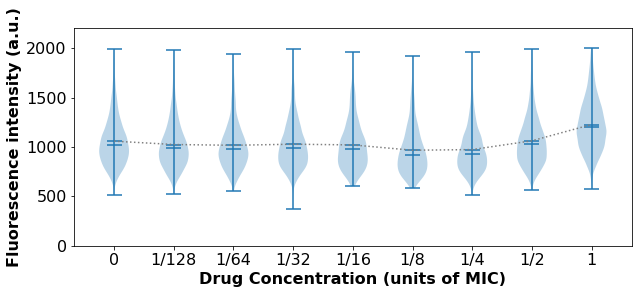

In [98]:
MGGT_Doses=['0', '1/128', '1/64', '1/32', '1/16','1/8','1/4','1/2','1'];
#MGGT_df=MGGT_dfbk.copy()

#lim_aspect=[.25, .75];   #<for amp
#lim_area=[5, 12];


ming=100
maxg=2e3

yy=[]
mggt_means=[]
xs=np.linspace(ming,maxg,1000)
poss=[]

row_df=MGGT_df[MGGT_df["season"]==2]
for ic,col in enumerate(cols):
    col_df=row_df[row_df["dose number"]==col]
    
    
    col_df=col_df[(col_df["Intensity_MC_Ch02"]<maxg)&(col_df["Intensity_MC_Ch02"]>ming)]
    
    this_gs=list(col_df["Intensity_MC_Ch02"])
    this_mean=np.mean(this_gs)
    #if(len(this_gs)<50):
    if(col>10):
        print("Skipped",ic,col)
        continue
    poss.append(ic)
    this_sd=np.std(this_gs)
    this_cv=this_sd/this_mean
    yy.append(this_gs)
    mggt_means.append(this_mean)
    print(ic,col,len(this_gs),this_mean,this_sd,this_cv)




fig=plt.figure(figsize=(10,4))
fig.set_facecolor('white')
plt.rcParams.update({'font.size': 16})
    
plt.violinplot(yy,positions=poss,showmeans=True,showmedians=True)
plt.plot(poss,mggt_means,ls=':',c='gray')
plt.ylim([0,2200])
plt.ylabel("Fluorescence intensity (a.u.)",fontweight='bold')
plt.xlabel("Drug Concentration (units of MIC)",fontweight='bold')
plt.xticks(poss,labels=MGGT_Doses)



out_fig_name=sfig_path+"sFig-2.pdf"
print("Saving fig as: \n",out_fig_name)
plt.savefig(out_fig_name,bbox_inches = 'tight',pad_inches = 0.1)
plt.show()

### Estimating CV for LB+AMP season

100 2500.0
2 1845 1027.675751264705 199.31692988691216 0.1939492389906287
	 1247 1046.7383250712421 193.9338171573227 0.18527440193242503
	 409 985.648119668747 207.61930521207037 0.21064242001683756
	 189 992.851792460446 197.35891729959428 0.19877983682791894
0.19823221959239387 

3 1648 997.2813394887023 198.94656260480514 0.19948890521385204
	 814 1001.8069908712712 191.96045560257002 0.19161421047343868
	 298 969.9966949907744 219.78552301266785 0.22658378543728774
	 536 1005.5778764942463 195.8618627791552 0.1947754294893498
0.20432447513335875 

4 1044 988.3708233007995 193.23635761623333 0.1955099776932853
	 315 979.8837891085445 216.30500171694115 0.22074556607751006
	 285 974.6170070917011 178.18386413259873 0.1828244970445437
	 444 1003.2204930984421 183.93823937268385 0.18334776914752948
0.19563927742319442 

5 1109 985.4289704446167 178.19459346180116 0.18082946493992497
	 80 941.3501941391999 168.2616715044713 0.17874503298778735
	 549 975.1774182929447 177.45692563779795

/usr/local/lib/python3.7/dist-packages/numpy/core/fromnumeric.py:3441: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
/usr/local/lib/python3.7/dist-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


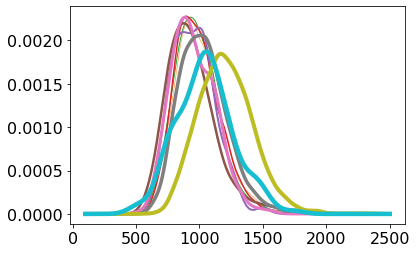

[0, 0, 0, 1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 5, 5, 6, 6, 6, 7, 7, 7, 8, 8, 9, 9]
[0, 0, 0, 1, 1, 1, 2, 2, 2, 3, 3, 3, 4, 4, 5, 5, 6, 6, 6, 7, 7, 7, 8, 8]


In [104]:


lim_aspect=[.4, .55];
lim_area=[5, 10];

MGGT_df=MGGT_df[(MGGT_df["Area_M02"]>lim_area[0])&(MGGT_df["Area_M02"]<lim_area[1])&
                (MGGT_df["Aspect Ratio_M02"]>lim_aspect[0])&(MGGT_df["Aspect Ratio_M02"]<lim_aspect[1])
                &(MGGT_df["Intensity_MC_Ch02"]<10000)
                #&(MGGT_df["Gradient RMS_M04_Ch04"]<1)
                &(MGGT_df["Gradient RMS_M02_Ch02"]>40)
                ]

cols=MGGT_df["dose number"].unique()
cols.sort()
rows=MGGT_df["season"].unique()
rows=[2]
ncols=len(cols)
nrows=len(rows)



this_g=MGGT_df["Intensity_MC_Ch02"]
maxg=this_g.max()
ming=this_g.min()
ming=100
maxg=2.5e3

print(ming,maxg)
xs=np.linspace(ming,maxg,1000)

MGGT_cvs=[]
MGGT_cvsx=[]
MGGT_cvsm=[]
MGGT_cvsxm=[]
MGGT_cvsm2=[]
MGGT_cvsxm2=[]


fig,ax=plt.subplots(figsize=(6,4)) 
for ic,col in enumerate(cols):
    col_df=MGGT_df[MGGT_df["dose number"]==col]
    #ax.set_title(col)
    for ir,row in enumerate(rows):
        row_df=col_df[col_df["season"]==row]
        row_df=row_df[row_df["Intensity_MC_Ch02"]<maxg]
        this_gs=row_df["Intensity_MC_Ch02"]
        this_mean=np.mean(this_gs)
        
        this_sd=np.std(this_gs)
        this_cv=this_sd/this_mean
        MGGT_cvsm.append(this_cv)
        MGGT_cvsxm.append(ic)
        print(col,this_gs.size,this_mean,this_sd,this_cv)
        if(this_gs.size>0):
            den=gaussian_kde(this_gs)
            ys=den(xs)
            yma=max(ys)
            ax.plot(xs,ys,lw=ic*.5)
        #ax.vlines(x=this_mean,ymin=0,ymax=yma,lw=ic*.5)
        reps=row_df["replicate"].unique()
        mcv=[]
        
        for rep in reps:
            t_df=row_df[row_df["replicate"]==rep]
            this_gs=t_df["Intensity_MC_Ch02"]
            this_mean=np.mean(this_gs)
            this_sd=np.std(this_gs)
            this_cv=this_sd/this_mean
            if(this_gs.size<10):
                #this_cv=np.nan
                continue
            MGGT_cvs.append(this_cv)
            MGGT_cvsx.append(ic)
            mcv.append(this_cv)
            print("\t",this_gs.size,this_mean,this_sd,this_cv)
            #ax.plot(xs,ys,c='k',alpha=.2)
        this_cv=np.mean(mcv)
        MGGT_cvsm2.append(this_cv)
        MGGT_cvsxm2.append(ic)
        print(this_cv,"\n")
#plt.yscale("log")
#plt.xscale("log")
plt.show()
print(MGGT_cvsx)
print(MGGT_cvsx[0:-2])

### Plotting CV vs Dose MGGT

lr0 LinregressResult(slope=-0.001041499875150912, intercept=0.19509708405226703, rvalue=-0.18463704042833728, pvalue=0.3665452190331333, stderr=0.0011316259924400345, intercept_stderr=0.005740230066906267)
lrm LinregressResult(slope=0.00023180396919515828, intercept=0.18991746426739775, rvalue=0.05279127467848264, pvalue=0.8848403847544768, stderr=0.0015502713092509551, intercept_stderr=0.00827618404037574)
lrm2 LinregressResult(slope=-0.000821452455169202, intercept=0.1939024638040744, rvalue=-0.228476802630618, pvalue=0.525490004770829, stderr=0.0012375230599042312, intercept_stderr=0.006606565274645354)


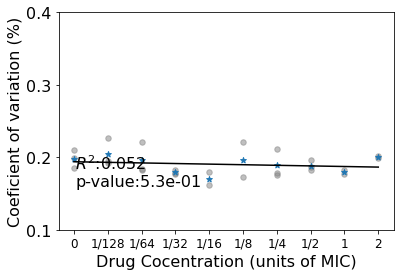

In [107]:
MGGT_Doses=['0', '1/128', '1/64', '1/32', '1/16','1/8','1/4','1/2','1'];
#strAs={'AMP=0','1/256 MIC', '1/128 MIC','1/64 MIC', '1/32 MIC','1/16 MIC','1/8 MIC','1/4 MIC','1/2 MIC','MIC'};


fig=plt.figure(figsize=(6,4))
fig.set_facecolor('white')
plt.rcParams.update({'font.size': 16})

MGGT_tcvsx=MGGT_cvsx[0:]
MGGT_tcvs=MGGT_cvs[0:]

MGGT_tcvsxm=MGGT_cvsxm[0:-1]
MGGT_tcvsm=MGGT_cvsm[0:-1]
MGGT_tcvsxm2=MGGT_cvsxm2[0:-1]
MGGT_tcvsm2=MGGT_cvsm2[0:-1]

tcvsx_ticks=list(set(MGGT_tcvsx))

MGGT_lr0=linregress(MGGT_tcvsx,MGGT_tcvs)
print("lr0",MGGT_lr0)

MGGT_lrm=linregress(MGGT_tcvsxm,MGGT_tcvsm)
print("lrm",MGGT_lrm)

MGGT_lrm2=linregress(MGGT_tcvsxm2,MGGT_tcvsm2)
print("lrm2",MGGT_lrm2)

lr_plot=MGGT_lrm2  #<-------------------------- change this
lry_plot=[x*lr_plot.slope+lr_plot.intercept for x in tcvsx_ticks]
plt.scatter(MGGT_tcvsx,MGGT_tcvs,s=30,c='gray',alpha=.5)
plt.scatter(MGGT_tcvsxm2,MGGT_tcvsm2,marker='*')
plt.plot(tcvsx_ticks,lry_plot,'k',label="regression")

plt.annotate(r"$R^2$:""%s\np-value:%s"%(round(lr_plot.rvalue**2,3),"{:.1e}".format(lr_plot.pvalue)), xy=(0.05, 0.2), xycoords='axes fraction')

plt.ylim([.1,.4])

plt.xticks(tcvsx_ticks,labels=Doses,fontsize=12)

plt.ylabel("Coeficient of variation (%)")
plt.xlabel("Drug Cocentration (units of MIC)")


plt.show()

## Plotting CV vs Dose pBGT and MGGT -> sFig 3

MGGT linear regressions:
Using all points
lr0	 LinregressResult(slope=-0.001972661170138639, intercept=0.1974212626445564, rvalue=-0.31025793600446383, pvalue=0.1400776922312423, stderr=0.001288664937261818, intercept_stderr=0.0059229541527985935)
Using means by all pops together
lrm	 LinregressResult(slope=0.00023180396919515828, intercept=0.18991746426739775, rvalue=0.05279127467848264, pvalue=0.8848403847544768, stderr=0.0015502713092509551, intercept_stderr=0.00827618404037574)
Using means by replicate means
lrm2	 LinregressResult(slope=-0.000821452455169202, intercept=0.1939024638040744, rvalue=-0.228476802630618, pvalue=0.525490004770829, stderr=0.0012375230599042312, intercept_stderr=0.006606565274645354)


pBGT linear regressions:
lr0 LinregressResult(slope=-0.022211239510932786, intercept=0.5877680101939987, rvalue=-0.7709448585560909, pvalue=6.195649848711278e-07, stderr=0.003467711868411505, intercept_stderr=0.018512515487263674)
lrm LinregressResult(slope=-0.017435174545927

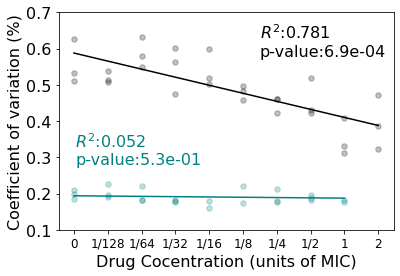

In [108]:
Doses=['0', '1/128', '1/64', '1/32', '1/16','1/8','1/4','1/2','1','2'];



fig=plt.figure(figsize=(6,4))
fig.set_facecolor('white')
plt.rcParams.update({'font.size': 16})

MGGT_tcvsx=MGGT_cvsx[0:-2]
MGGT_tcvs=MGGT_cvs[0:-2]

MGGT_tcvsxm=MGGT_cvsxm[0:-1]
MGGT_tcvsm=MGGT_cvsm[0:-1]
MGGT_tcvsxm2=MGGT_cvsxm2[0:-1]
MGGT_tcvsm2=MGGT_cvsm2[0:-1]

tcvsx_ticks=list(set(MGGT_tcvsx))


print("MGGT linear regressions:")

MGGT_lr0=linregress(MGGT_tcvsx,MGGT_tcvs)
print("Using all points\nlr0\t",MGGT_lr0)

MGGT_lrm=linregress(MGGT_tcvsxm,MGGT_tcvsm)
print("Using means by all pops together\nlrm\t",MGGT_lrm)

MGGT_lrm2=linregress(MGGT_tcvsxm2,MGGT_tcvsm2)
print("Using means by replicate means\nlrm2\t",MGGT_lrm2)
mggt_color='teal'
lr_plot=MGGT_lrm2  #<-------------------------- change this
lry_plot=[x*lr_plot.slope+lr_plot.intercept for x in tcvsx_ticks]
plt.scatter(MGGT_tcvsx,MGGT_tcvs,s=30,c=mggt_color,alpha=.25)
#plt.scatter(MGGT_tcvsxm2,MGGT_tcvsm2,marker='*',c=mggt_color)
plt.plot(tcvsx_ticks,lry_plot,'k',label="regression",c=mggt_color)

plt.annotate(r"$R^2$:""%s\np-value:%s"%(round(lr_plot.rvalue**2,3),"{:.1e}".format(lr_plot.pvalue)), xy=(0.05, 0.3), xycoords='axes fraction',color=mggt_color)


pBGT_tcvsx=pBGT_cvsx[0:-2]
pBGT_tcvs=pBGT_cvs[0:-2]

pBGT_tcvsxm=pBGT_cvsxm[0:-1]
pBGT_tcvsm=pBGT_cvsm[0:-1]
pBGT_tcvsxm2=pBGT_cvsxm2[0:-1]
pBGT_tcvsm2=pBGT_cvsm2[0:-1]

tcvsx_ticks=list(set(pBGT_tcvsx))

pBGT_lr0=linregress(pBGT_tcvsx,pBGT_tcvs)
print("\n\npBGT linear regressions:")
print("lr0",pBGT_lr0)
pBGT_lrm=linregress(pBGT_tcvsxm,pBGT_tcvsm)

print("lrm",pBGT_lrm)
pBGT_lrm2=linregress(pBGT_tcvsxm2,pBGT_tcvsm2)

print("lrm2",pBGT_lrm2)
pbgt_color='k'
lr_plot=pBGT_lrm2  #<-------------------------- change this
lry_plot=[x*lr_plot.slope+lr_plot.intercept for x in tcvsx_ticks]
plt.scatter(pBGT_tcvsx,pBGT_tcvs,s=30,c=pbgt_color,alpha=.25)
#plt.scatter(pBGT_tcvsxm2,pBGT_tcvsm2,marker='*',c=pbgt_color)
plt.plot(tcvsx_ticks,lry_plot,'k',label="regression",c=pbgt_color)

plt.annotate(r"$R^2$:""%s\np-value:%s"%(round(lr_plot.rvalue**2,3),"{:.1e}".format(lr_plot.pvalue)), xy=(0.6, 0.80), xycoords='axes fraction',color=pbgt_color)

plt.ylim([.1,.7])

plt.xticks(tcvsx_ticks,labels=Doses,fontsize=12)

plt.ylabel("Coefficient of variation (%)")
plt.xlabel("Drug Cocentration (units of MIC)")


#plt.rcParams.update({'font.size': 16})
out_fig_name=sfig_path+"sFig_3.pdf"
print("Saving fig as: \n",out_fig_name)
plt.savefig(out_fig_name,bbox_inches = 'tight',pad_inches = 0.1)
plt.show()
